`DeepField` framework can be used for advanced data manipulation gained as results of `JutulDarcy.jl`, a fully differentiable reservoir simulator written in `Julia`. Interconnection between `Field` object and `JutulDarcy` can be established by python wrapper `PyJutulDarcy` (https://github.com/sintefmath/PyJutulDarcy) that can be installed as usual `pip install jutuldarcy`.

Workflow consists of the following steps
- loading "empty" model that doesn't contain dynamical data (pressure, saturations and well-rates) as `Field` object
- loading the same model but using `PyJutulDarcy` methods for reading `.DATA` files
- running simulation in `PyJutulDarcy`. Results are python dicts and numpy arrays
- assign arrays to `Field` model as attributes

Loading necessary libraries

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt

import jutuldarcy as jd
from juliacall import Main as jl
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")

from deepfield import Field

C:\Users\mushe\anaconda3\envs\deepfield\Lib\site-packages\jutuldarcy\julia_import.py:9: UserWarning: juliacall module already imported. Make sure that you have set the environment variable `PYTHON_JULIACALL_HANDLE_SIGNALS=yes` to avoid segfaults. Also note that jutuldarcy will not be able to configure `PYTHON_JULIACALL_THREADS` or `PYTHON_JULIACALL_OPTLEVEL` for you.
  warnings.warn(


Setting up `.DATA`-file path and loading static reservoir model as `Field` object

In [3]:
path = '../open_data/egg/Egg_Model_ECL.DATA'
model = Field(path).load()

INFO:Field:Using default config.
INFO:Field:Start reading Egg_Model_ECL.DATA
INFO:Field:Reading section RUNSPEC
INFO:Field:[Egg_Model_ECL.DATA:9] Loading TITLE
INFO:Field:[Egg_Model_ECL.DATA:16] Loading DIMENS
INFO:Field:[Egg_Model_ECL.DATA:19] Loading METRIC
INFO:Field:[Egg_Model_ECL.DATA:20] Loading OIL
INFO:Field:[Egg_Model_ECL.DATA:21] Loading WATER
INFO:Field:[Egg_Model_ECL.DATA:41] Loading START
INFO:Field:Reading section GRID
INFO:Field:[Egg_Model_ECL.DATA:55] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\ACTIVE.INC
INFO:Field:Start reading ACTIVE.INC
INFO:Field:[ACTIVE.INC:1] Loading ACTNUM
INFO:Field:Finish reading ACTIVE.INC
INFO:Field:[Egg_Model_ECL.DATA:58] Loading DX
INFO:Field:[Egg_Model_ECL.DATA:62] Loading DY
INFO:Field:[Egg_Model_ECL.DATA:66] Loading DZ
INFO:Field:[Egg_Model_ECL.DATA:69] Loading TOPS
INFO:Field:[Egg_Model_ECL.DATA:73] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\mDARCY.INC
INFO:Field:Start reading mDARCY.INC

`PyJutulDarcy` allows reading `.DATA` files that is converted to `Jutul` case dictionary-like datastructure that contains `.DATA` file sections as key-value pairs

In [4]:
case = jd.setup_case_from_data_file(path)
case

Jutul case with 120 time-steps (9 years, 44 weeks, 4.817 days) and forces for each step.

Model:

MultiModel with 14 models and 36 cross-terms. 37142 equations, 37142 degrees of freedom and 141596 parameters.

  models:
    1) Reservoir (37106x37106)
       ImmiscibleSystem with JutulDarcy.AqueousPhase, JutulDarcy.LiquidPhase
       ∈ MinimalTPFATopology (18553 cells, 52113 faces)
    2) PROD2 (2x2)
       ImmiscibleSystem with JutulDarcy.AqueousPhase, JutulDarcy.LiquidPhase
       ∈ SimpleWell [PROD2] (1 nodes, 0 segments, 7 perforations)
    3) INJECT5 (2x2)
       ImmiscibleSystem with JutulDarcy.AqueousPhase, JutulDarcy.LiquidPhase
       ∈ SimpleWell [INJECT5] (1 nodes, 0 segments, 7 perforations)
    4) INJECT4 (2x2)
       ImmiscibleSystem with JutulDarcy.AqueousPhase, JutulDarcy.LiquidPhase
       ∈ SimpleWell [INJECT4] (1 nodes, 0 segments, 7 perforations)
    5) INJECT2 (2x2)
       ImmiscibleSystem with JutulDarcy.AqueousPhase, JutulDarcy.LiquidPhase
       ∈ SimpleWell [INJ

Once assembled `Jutul` case structure can be passed right into `PyJutulDarcy` reservoir simulator. 

At the same time `.DATA`-files can be directly loaded from the disk and simulated in `PyJutulDarcy`

In [5]:
res = jd.simulate_data_file(path, convert = True)

Jutul: Simulating 9 years, 44.69 weeks as 120 report steps


Progress   2%|█                                          |  ETA: 0:31:43
   Progress: Solving step 2/120 (1.67% of time interval complete)
   Stats: 34 iterations in 30.26 s (890.07 ms each)

Progress   2%|██                                         |  ETA: 0:23:57
   Progress: Solving step 3/120 (2.50% of time interval complete)
   Stats: 49 iterations in 33.20 s (677.55 ms each)

Progress   3%|██                                         |  ETA: 0:18:45
   Progress: Solving step 4/120 (3.33% of time interval complete)
   Stats: 59 iterations in 35.01 s (593.32 ms each)

Progress   4%|██                                         |  ETA: 0:15:25
   Progress: Solving step 5/120 (4.17% of time interval complete)
   Stats: 69 iterations in 36.42 s (527.83 ms each)

Progress   5%|███                                        |  ETA: 0:13:27
   Progress: Solving step 6/120 (5.00% of time interval complete)
   Stats: 80 iterations in 38.63 s (482.83 ms each)

Progress   6%|███                       

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 120 steps │ 154 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   4.35833 │        3.3961 │  523 (0) │
│ Linearization  │   5.64167 │        4.3961 │  677 (0) │
│ Linear solver  │   20.8417 │       16.2403 │ 2501 (0) │
│ Precond apply  │   41.6833 │       32.4805 │ 5002 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬──────────╮
│ Timing type   │     Each │   Relative │    Total │
│               │       ms │ Percentage │        s │
├───────────────┼──────────┼────────────┼──────────┤
│ Properties    │   5.7394 │     2.67 % │   3.0017 │
│ Equations     │  16.8505 │    10.14 % │  11.4078 │
│ Assembly      │  11.0568 │     6.65 % │   7.4854 │
│ Linear solve  │  15.9463 │     7.41 % │   8.3399 │
│ Linear setup  │  79.8995 │    37.14 % │  41.7875 │
│

In [6]:
res

{'WELLS': {'PROD2': {'WWPT': array([7.28193217e-11, 7.28193217e-11, 7.33194634e-11, 7.33194634e-11,
          4.53315106e+06, 4.93574745e+07, 1.27428615e+08, 2.40574189e+08,
          3.95379850e+08, 5.97114300e+08, 8.51950334e+08, 1.15349789e+09,
          1.50488947e+09, 1.90073955e+09, 2.33495501e+09, 2.80068574e+09,
          3.31081721e+09, 3.87341740e+09, 4.47615541e+09, 5.10724110e+09,
          5.75567377e+09, 6.41119144e+09, 7.07425245e+09, 7.74695128e+09,
          8.42693814e+09, 9.11260003e+09, 9.80240444e+09, 1.04956927e+10,
          1.11915592e+10, 1.18892865e+10, 1.25884598e+10, 1.32881084e+10,
          1.39877666e+10, 1.46872218e+10, 1.53863275e+10, 1.60850116e+10,
          1.67831649e+10, 1.74809426e+10, 1.81788218e+10, 1.88773426e+10,
          1.95771216e+10, 2.02790193e+10, 2.09841018e+10, 2.16932263e+10,
          2.24070113e+10, 2.31258160e+10, 2.38493210e+10, 2.45770703e+10,
          2.53086098e+10, 2.60436129e+10, 2.67817030e+10, 2.75226871e+10,
          2.

In the simulation results there won't be data for initial state. So to complete output it is necessary to refer to assembled `case` data structure. Here `JuliaCall` features are used for running commands from `Julia`

In [7]:
state0_pressure = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Pressure]")(case.state0)
).reshape(1, -1)

state0_sats = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Saturations]")(case.state0)
).reshape(1, 2, -1)

As the results returned by `jd.simulate_data_file` contain python dictionary with numoy values, they can be manipulated inside python scientific workflow.

First it is necessary to reshape state-arrays (pressure and saturations) so every key of the new data sructure contains arrays for all timesteps

In [12]:
n_steps = len(res['STATES'])
jd_pressure = np.array([res['STATES'][i]['Pressure'] for i in range(n_steps)])
jd_sats = np.array([res['STATES'][i]['Saturations'] for i in range(n_steps)])

Then reshape initial states

In [13]:
jd_pressure0 = np.vstack([state0_pressure, jd_pressure])
jd_sats0 = np.vstack([state0_sats, jd_sats])

Draw mean pressure and saturations

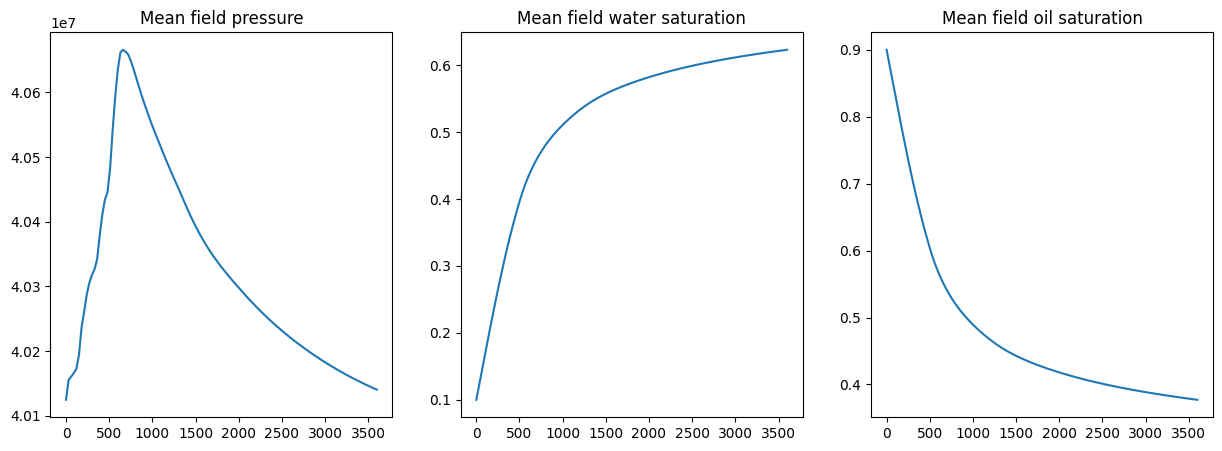

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

days = np.hstack([0., res["DAYS"]])
pressure = jd_pressure.mean(axis=1)
swat = jd_sats[:, 0, :].mean(axis=1)
soil = jd_sats[:, 1, :].mean(axis=1)

ax[0].set_title("Mean field pressure")
ax[0].plot(days, pressure)
ax[1].set_title("Mean field water saturation")
ax[1].plot(days, swat)
ax[2].set_title("Mean field oil saturation")
ax[2].plot(days, soil)

Model downloaded as Field object doesn't contain states

In [19]:
model.states.attributes

('SOIL', 'PRESSURE', 'SWAT')

But now with computed saturation and pressure dynamics states can be assigned to deepfield's model

In [18]:
model.states.pressure = jd_pressure
model.states.soil = jd_sats[:, 1, :]
model.states.swat = jd_sats[:, 0, :]

Cast 1D-arrays assigned to the model's states as 3D ones

In [20]:
model.states.to_spatial()

Then we spatial-distributed properties as pressure and saturations can be visualizaed immediately

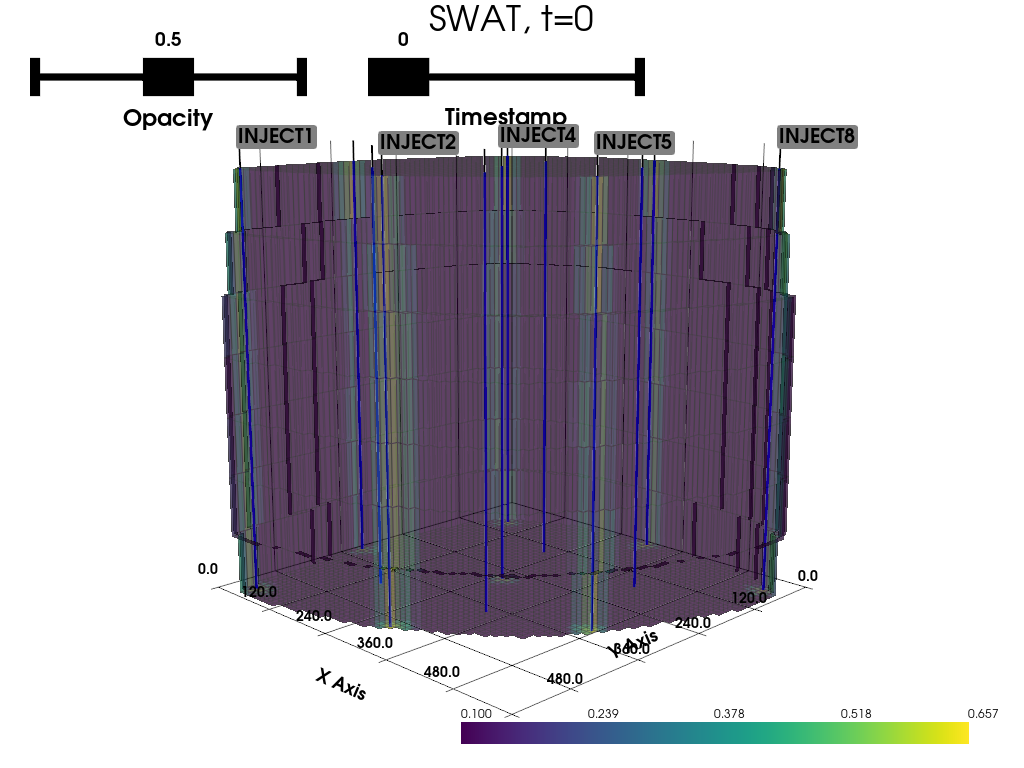

In [21]:
model.show(attr="SWAT", notebook=True)

But adding computed well rates requires additional efforts

Extracting report dates

In [29]:
n_timestamps = len(res["DAYS"])
start_date = case.input_data["RUNSPEC"]["START"]
timestamps = [start_date + timedelta(days=res["DAYS"][i]) for i in range(n_timestamps)]
dates = pd.DataFrame({"DATE": timestamps})

Well states can be updated from dictionary welldata with keys - well names, and values - dataframes with the well states. So first empty welldata dictionary is created

In [30]:
welldata = {}

Auxiliary function for collecting computed well rates into dataframe

In [31]:
def well_states(well):
    states_df = pd.concat([dates, pd.DataFrame(well)], axis=1)
    record0 = pd.DataFrame([[start_date] + [0.0]*(len(well.columns))], columns = states_df.columns)
    states_df = pd.concat([record0, states_df])
    return states_df

In [32]:
wellnames = res["WELLS"].keys()
welldata = {w: {"RESULTS": well_states(pd.DataFrame(res["WELLS"][w]))} for w in wellnames}

Assigning `welldata` structure to wells by `wells.update` method

In [33]:
model.wells.update(welldata)

Now it is possible to show well rates as a part of Field model

In [34]:
model.wells.show_rates()

interactive(children=(Dropdown(description='wellname', options=('FIELD', '1', 'INJECT1', 'INJECT2', 'INJECT3',…